# Dry Eye Disease Prediction 


# Introduction : 

# Data Loading

In [37]:
import numpy as np
import pandas as pd

In [38]:
df = pd.read_csv('../data/Dry_Eye_Dataset.csv')


In [39]:
df.head(2)

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
0,F,24,9.5,2,1,137/89,67,3000,31,161,...,N,Y,Y,N,8.7,N,Y,Y,N,Y
1,M,39,9.6,2,3,108/64,60,12000,74,164,...,N,Y,Y,N,9.6,Y,N,N,Y,Y


In [40]:
df.tail(2)

,Gender,Age,Sleep duration,Sleep quality,Stress level,Blood pressure,Heart rate,Daily steps,Physical activity,Height,...,Smoking,Medical issue,Ongoing medication,Smart device before bed,Average screen time,Blue-light filter,Discomfort Eye-strain,Redness in eye,Itchiness/Irritation in eye,Dry Eye Disease
19998,M,38,4.5,3,3,136/70,60,3000,115,170,...,Y,N,Y,N,2.2,N,N,N,Y,Y
19999,M,37,5.0,5,3,96/90,73,13000,57,188,...,N,Y,Y,Y,4.2,Y,N,N,N,N


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Gender                       20000 non-null  object 
 1   Age                          20000 non-null  int64  
 2   Sleep duration               20000 non-null  float64
 3   Sleep quality                20000 non-null  int64  
 4   Stress level                 20000 non-null  int64  
 5   Blood pressure               20000 non-null  object 
 6   Heart rate                   20000 non-null  int64  
 7   Daily steps                  20000 non-null  int64  
 8   Physical activity            20000 non-null  int64  
 9   Height                       20000 non-null  int64  
 10  Weight                       20000 non-null  int64  
 11  Sleep disorder               20000 non-null  object 
 12  Wake up during night         20000 non-null  object 
 13  Feel sleepy duri

# Data preprocessing

In [42]:
# Handling Missing Values
df.isnull().sum()  # identify missing values

# Strategy: numerical -> median, categorical -> mode
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include='object').columns

# Imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [43]:
#  Remove Duplicates
df = df.drop_duplicates()

# Handling Outliers

Gender                          object
Age                              int64
Sleep duration                 float64
Sleep quality                    int64
Stress level                     int64
Blood pressure                  object
Heart rate                       int64
Daily steps                      int64
Physical activity                int64
Height                           int64
Weight                           int64
Sleep disorder                  object
Wake up during night            object
Feel sleepy during day          object
Caffeine consumption            object
Alcohol consumption             object
Smoking                         object
Medical issue                   object
Ongoing medication              object
Smart device before bed         object
Average screen time            float64
Blue-light filter               object
Discomfort Eye-strain           object
Redness in eye                  object
Itchiness/Irritation in eye     object
Dry Eye Disease          

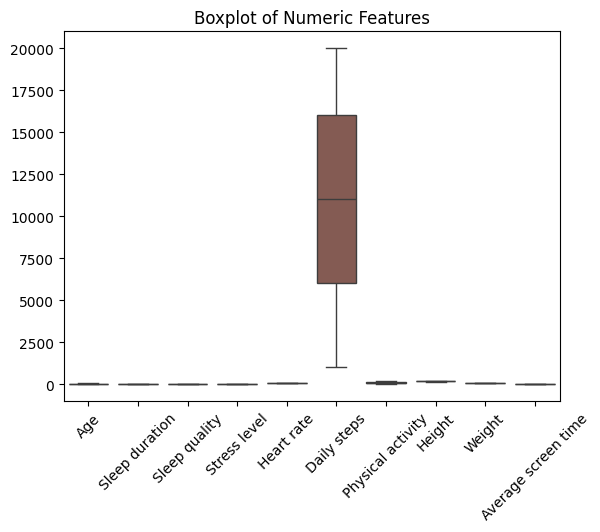

Original shape: (20000, 26)
After outlier removal: (20000, 26)


In [44]:

import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('../data/Dry_Eye_Dataset.csv')

# Step 1: Check column types
print(df.dtypes)

# Step 2: Select numeric columns for outlier detection
df_numeric = df.select_dtypes(include='number')

# Optional: Visualize numeric columns
sns.boxplot(data=df_numeric)
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()

# Step 3: IQR-based outlier removal
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only rows without outliers
df_no_outliers = df[~((df_numeric < lower_bound) | (df_numeric > upper_bound)).any(axis=1)]

# Show how many rows were removed
print(f"Original shape: {df.shape}")
print(f"After outlier removal: {df_no_outliers.shape}")


# EDA 

In [45]:
df.dtypes

Gender                          object
Age                              int64
Sleep duration                 float64
Sleep quality                    int64
Stress level                     int64
Blood pressure                  object
Heart rate                       int64
Daily steps                      int64
Physical activity                int64
Height                           int64
Weight                           int64
Sleep disorder                  object
Wake up during night            object
Feel sleepy during day          object
Caffeine consumption            object
Alcohol consumption             object
Smoking                         object
Medical issue                   object
Ongoing medication              object
Smart device before bed         object
Average screen time            float64
Blue-light filter               object
Discomfort Eye-strain           object
Redness in eye                  object
Itchiness/Irritation in eye     object
Dry Eye Disease          

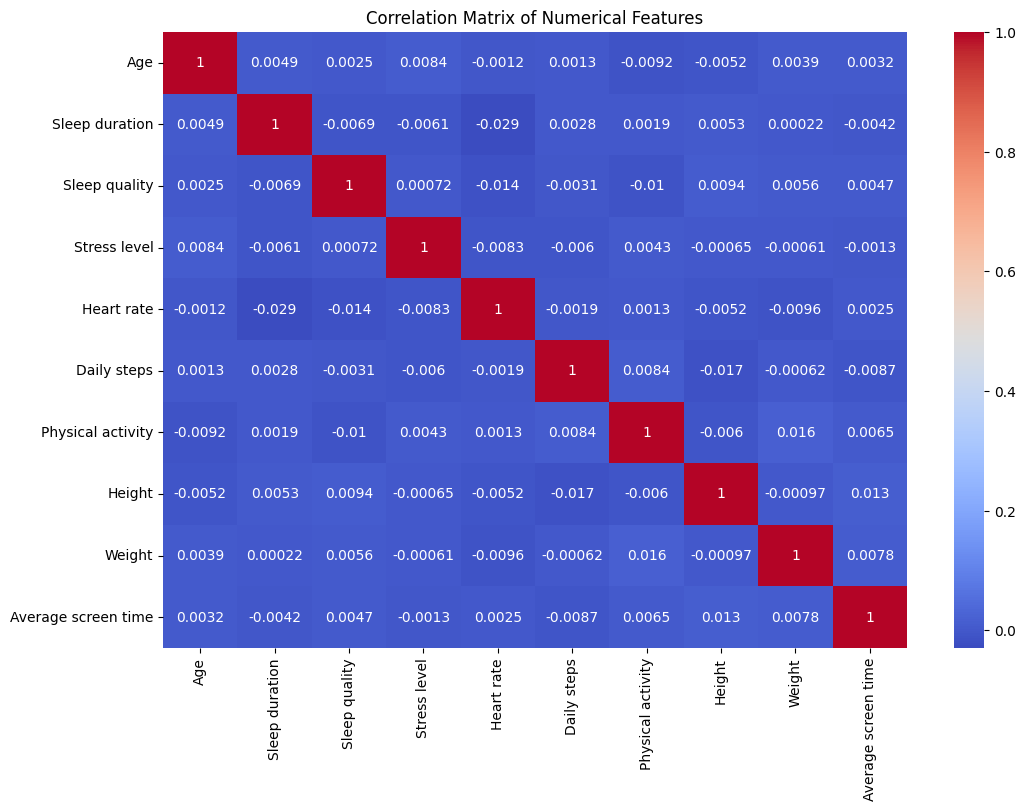

In [46]:
# Only select numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute and visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Features")
plt.show()


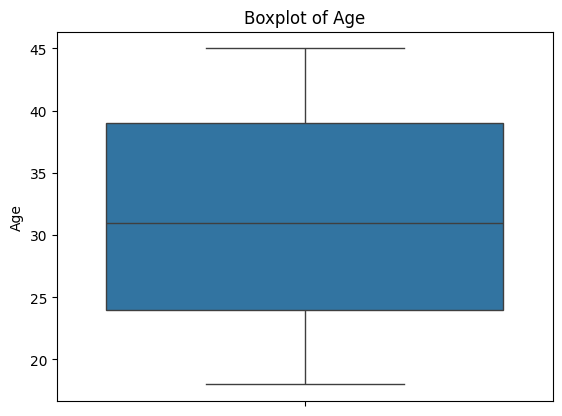

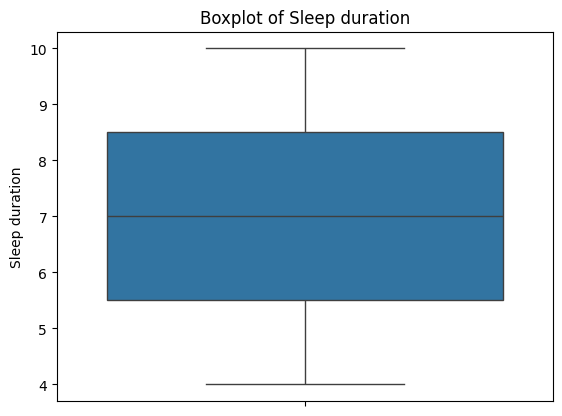

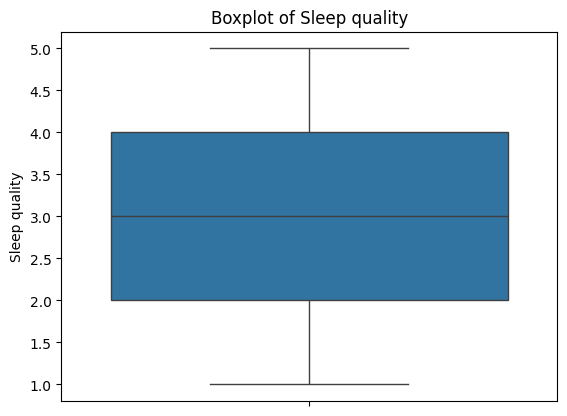

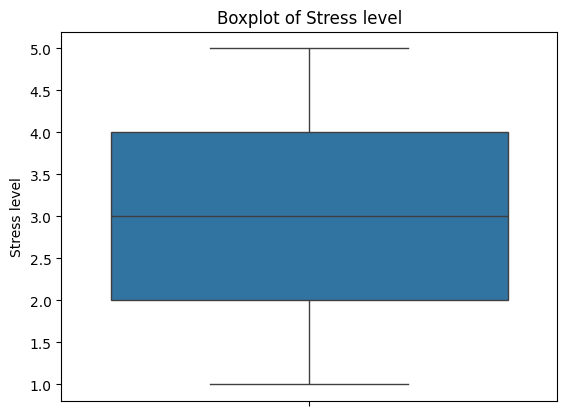

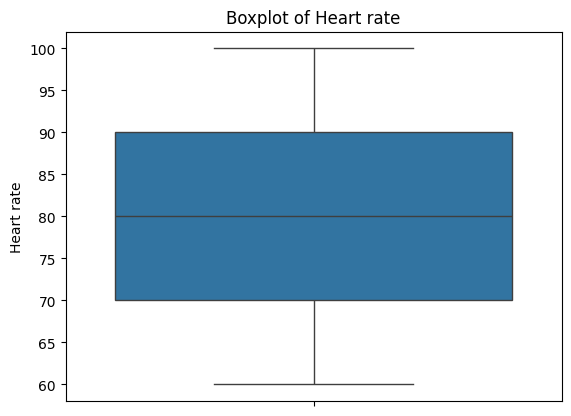

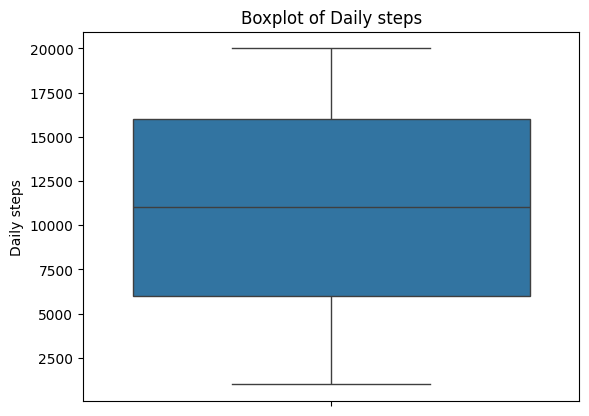

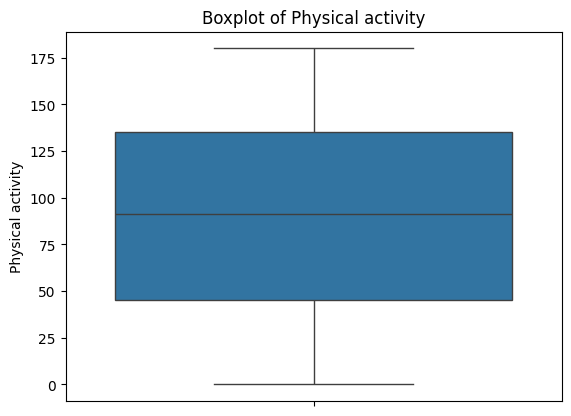

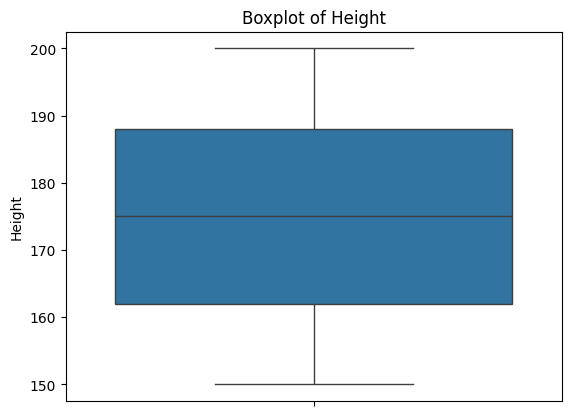

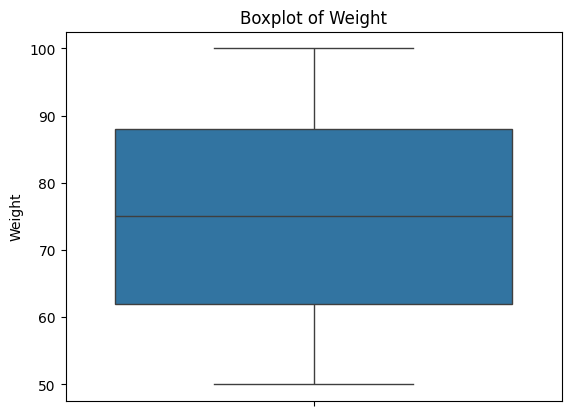

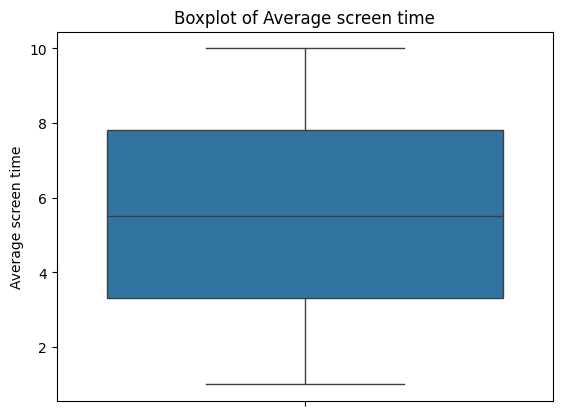

In [47]:
for column in df_numeric.columns:
    sns.boxplot(y=df_numeric[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

# Feature Engineering

In [48]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=['Dry Eye Disease'])
y = df['Dry Eye Disease']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# Train Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=10)  # Select top 10 features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Use in your best model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_selected, y_train)                                                             

RandomForestClassifier(random_state=42)

In [51]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", scores.mean())


Cross-validation accuracy scores: [0.6953125 0.695     0.6934375 0.69375   0.6959375]
Mean accuracy: 0.6946874999999999


# Model Building

In [52]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model


In [53]:
from sklearn.ensemble import  VotingClassifier

from sklearn.metrics import accuracy_score

# Increase max_iter to ensure convergence
ensemble = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(random_state=42)),
    ('lr', LogisticRegression(max_iter=1000))  
], voting='soft')

ensemble.fit(X_train, y_train)
ensemble_preds = ensemble.predict(X_test)

print("Voting Ensemble Accuracy:", accuracy_score(y_test, ensemble_preds))


Voting Ensemble Accuracy: 0.6985


# Model Evaluation

In [54]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

for name, model in fitted_models.items():
    print(f"\n{name} Performance:")
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Random Forest Performance:
Accuracy: 0.70325
              precision    recall  f1-score   support

           N       0.63      0.22      0.33      1307
           Y       0.71      0.94      0.81      2693

    accuracy                           0.70      4000
   macro avg       0.67      0.58      0.57      4000
weighted avg       0.69      0.70      0.65      4000


Gradient Boosting Performance:
Accuracy: 0.70075
              precision    recall  f1-score   support

           N       0.61      0.23      0.33      1307
           Y       0.71      0.93      0.81      2693

    accuracy                           0.70      4000
   macro avg       0.66      0.58      0.57      4000
weighted avg       0.68      0.70      0.65      4000


Logistic Regression Performance:
Accuracy: 0.6535
              precision    recall  f1-score   support

           N       0.44      0.21      0.29      1307
           Y       0.69      0.87      0.77      2693

    accuracy                       

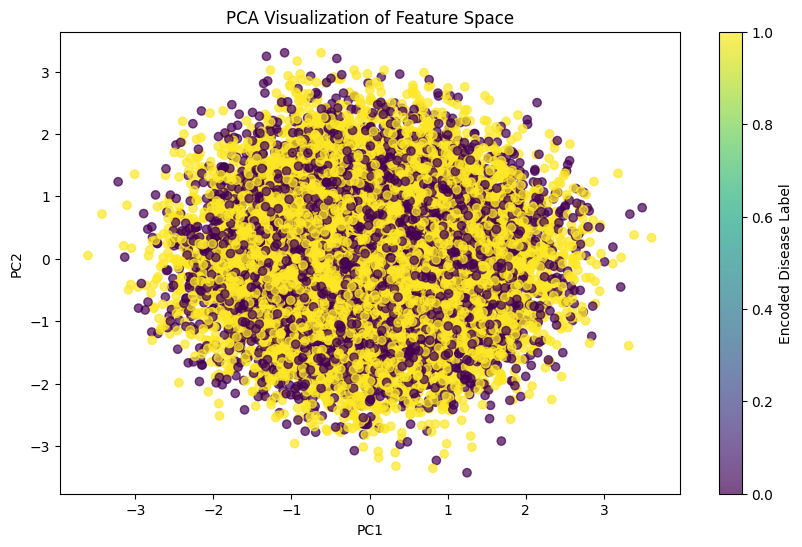

In [55]:
# Flatten label lists into single string values
y_train_flat = y_train.apply(lambda x: x[0] if isinstance(x, list) else x)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_train.toarray())  # Convert to dense if sparse

# Flatten the labels
y_train_flat = y_train.apply(lambda x: x[0] if isinstance(x, list) else x)

# Encode classes into numbers for color mapping
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
color_labels = le.fit_transform(y_train_flat)

plt.figure(figsize=(10, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=color_labels, cmap='viridis', alpha=0.7)
plt.title("PCA Visualization of Feature Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Encoded Disease Label')
plt.show()


# Explainability with SHAP

In [56]:
X_train_dense = X_train.toarray() if hasattr(X_train, "toarray") else X_train
X_test_dense = X_test.toarray() if hasattr(X_test, "toarray") else X_test


In [57]:
feature_names = preprocessor.get_feature_names_out()

In [58]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier()
best_model.fit(X_train_dense, y_train)

RandomForestClassifier()

In [59]:
import shap

# Sample test data
X_sample = X_test_dense[:300]
y_sample = y_test[:300]

100%|===================| 7994/8000 [30:26<00:01]        

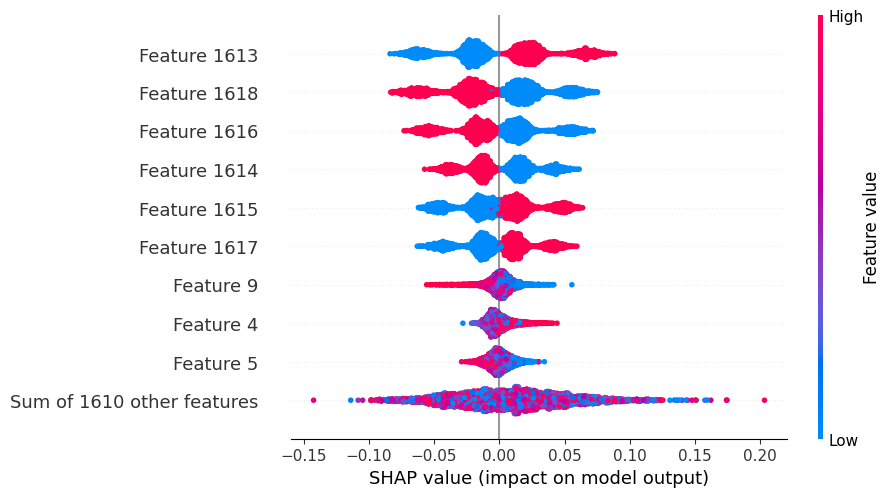

In [60]:
explainer = shap.Explainer(best_model, X_train_dense)
shap_values = explainer(X_test_dense, check_additivity=False)
shap.plots.beeswarm(shap_values[:,:,0])

# Hyper Parameter Tunning

In [61]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': None, 'n_estimators': 150}


# Deployment

In [63]:
import joblib

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')


['preprocessor.pkl']

In [64]:
# Save feature selector (only if used)
try:
    joblib.dump(selector, 'selector.pkl')
except:
    print("Selector not used or already inside preprocessor.")

In [65]:
try:
    preprocessor = joblib.load("preprocessor.pkl")
    print("Preprocessor loaded.")
except Exception as e:
    print(f"Failed to load preprocessor: {e}")
    preprocessor = None

try:
    selector = joblib.load("selector.pkl")
    print("Feature selector loaded.")
except:
    selector = None
    print("Feature selector not used or not found.")


Preprocessor loaded.
Feature selector loaded.


In [4]:
import joblib
import pandas as pd
from flask import Flask, request, jsonify

# Initialize Flask app
app = Flask(__name__)

# === Load saved model, preprocessor, and selector (if used) ===
try:
    model = joblib.load('best_model.pkl')
    print("Model loaded.")
except Exception as e:
    print(f"Failed to load model: {e}")
    model = None

try:
    preprocessor = joblib.load('preprocessor.pkl')
    print("Preprocessor loaded.")
except Exception as e:
    print(f"Failed to load preprocessor: {e}")
    preprocessor = None

try:
    selector = joblib.load('selector.pkl')  # Optional
    print("Feature selector loaded.")
except Exception as e:
    selector = None
    print("Feature selector not used or not found.")

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    print("Received data:", data)

    # === Auto-fix known typos ===
    if "Alochol consumption" in data:
        data["Alcohol consumption"] = data.pop("Alochol consumption")
    if "Sleep Duration" in data:
        data["Sleep duration"] = data.pop("Sleep Duration")
    if "Ongoing medication " in data:
        data["Ongoing medication"] = data.pop("Ongoing medication ")

    # === Handle blood pressure input ===
    if "Blood pressure" in data:
        try:
            if isinstance(data["Blood pressure"], str):
                systolic, diastolic = map(int, data["Blood pressure"].split("/"))
            elif isinstance(data["Blood pressure"], int):  # fallback
                systolic, diastolic = data["Blood pressure"], 80  # assume default diastolic
            else:
                raise ValueError("Invalid BP format")
            data["Systolic BP"] = systolic
            data["Diastolic BP"] = diastolic
            del data["Blood pressure"]
        except Exception as e:
            return jsonify({"error": "Invalid blood pressure format"}), 400

    # === Create DataFrame ===
    input_data = pd.DataFrame([data])
    print("\nInput DataFrame:\n", input_data)

    # === Check column alignment ===
    if preprocessor is None:
        return jsonify({"error": "Preprocessor not loaded"}), 500

    expected_cols = list(preprocessor.feature_names_in_)
    missing_cols = set(expected_cols) - set(input_data.columns)
    if missing_cols:
        return jsonify({"error": f"Missing required features: {missing_cols}"}), 400

    input_data = input_data.reindex(columns=expected_cols, fill_value=0)

    # === Preprocess input ===
    try:
        processed_data = preprocessor.transform(input_data)
        print("\nPreprocessed Data Shape:", processed_data.shape)
    except Exception as e:
        return jsonify({"error": f"Preprocessing failed: {e}"}), 500

    # === Feature selection if applicable ===
    if selector:
        try:
            processed_data = selector.transform(processed_data)
            print("Feature selection applied.")
        except Exception as e:
            return jsonify({"error": f"Feature selection failed: {e}"}), 500

    # === Predict ===
    try:
        prediction = model.predict(processed_data)
        print("Prediction:", prediction)
    except Exception as e:
        return jsonify({"error": f"Prediction failed: {e}"}), 500

    return jsonify({'prediction': prediction.tolist()})

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok'})

# === Local testing ===
if __name__ == "__main__":
    with app.test_client() as client:
        print("\n--- Health Check ---")
        print(client.get('/health').json)

        sample_input = {
            "Gender": 1,
            "Age": 24,
            "Sleep Duration": 9.5,
            "Sleep quality": 2,
            "Stress level": 1,
            "Blood pressure": "137/85",  # Must be string with "/"
            "Heart rate": 67,
            "Daily steps": 3000,
            "Physical activity": 31,
            "Height": 161,
            "Weight": 69,
            "Sleep disorder": 1,
            "Wake up during night": 0,
            "Feel sleepy during day": 0,
            "Caffeine consumption": 0,
            "Alochol consumption": 0,
            "Smoking": 0,
            "Medical issue": 1,
            "Ongoing medication ": 1,
            "Smart device before bed": 0,
            "Average screen time": 8.7,
            "Blue-light filter": 0,
            "Discomfort Eye-strain": 1,
            "Redness in eye": 1,
            "Itchiness/Irritation in eye": 0
        }

        print("\n--- Predicting on sample ---")
        print(client.post('/predict', json=sample_input).json)


Model loaded.
Preprocessor loaded.
Feature selector loaded.

--- Health Check ---
{'status': 'ok'}

--- Predicting on sample ---
Received data: {'Age': 24, 'Alochol consumption': 0, 'Average screen time': 8.7, 'Blood pressure': '137/85', 'Blue-light filter': 0, 'Caffeine consumption': 0, 'Daily steps': 3000, 'Discomfort Eye-strain': 1, 'Feel sleepy during day': 0, 'Gender': 1, 'Heart rate': 67, 'Height': 161, 'Itchiness/Irritation in eye': 0, 'Medical issue': 1, 'Ongoing medication ': 1, 'Physical activity': 31, 'Redness in eye': 1, 'Sleep Duration': 9.5, 'Sleep disorder': 1, 'Sleep quality': 2, 'Smart device before bed': 0, 'Smoking': 0, 'Stress level': 1, 'Wake up during night': 0, 'Weight': 69}

Input DataFrame:
    Age  Average screen time  Blue-light filter  Caffeine consumption  \
0   24                  8.7                  0                     0   

   Daily steps  Discomfort Eye-strain  Feel sleepy during day  Gender  \
0         3000                      1                   